In [1]:
#libraries needed
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge

import xgboost as xgb
import lightgbm as lgb
import category_encoders as ce
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All libraries loaded!')

✅ All libraries loaded!


In [4]:
!kaggle datasets download -d sazidthe1/data-science-salaries -p ./data --unzip
print("Files:", os.listdir('./data'))

Dataset URL: https://www.kaggle.com/datasets/sazidthe1/data-science-salaries
License(s): DbCL-1.0
100%|███████████████████████████████████████| 57.3k/57.3k [00:00<00:00, 257kB/s]

Files: ['data_science_salaries.csv']


In [6]:
df = pd.read_csv('./data/data_science_salaries.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (6599, 11)
Columns: ['job_title', 'experience_level', 'employment_type', 'work_models', 'work_year', 'employee_residence', 'salary', 'salary_currency', 'salary_in_usd', 'company_location', 'company_size']


,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [7]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

job_title             object
experience_level      object
employment_type       object
work_models           object
work_year              int64
employee_residence    object
salary                 int64
salary_currency       object
salary_in_usd          int64
company_location      object
company_size          object
dtype: object

Missing values:
job_title             0
experience_level      0
employment_type       0
work_models           0
work_year             0
employee_residence    0
salary                0
salary_currency       0
salary_in_usd         0
company_location      0
company_size          0
dtype: int64

Duplicates: 0


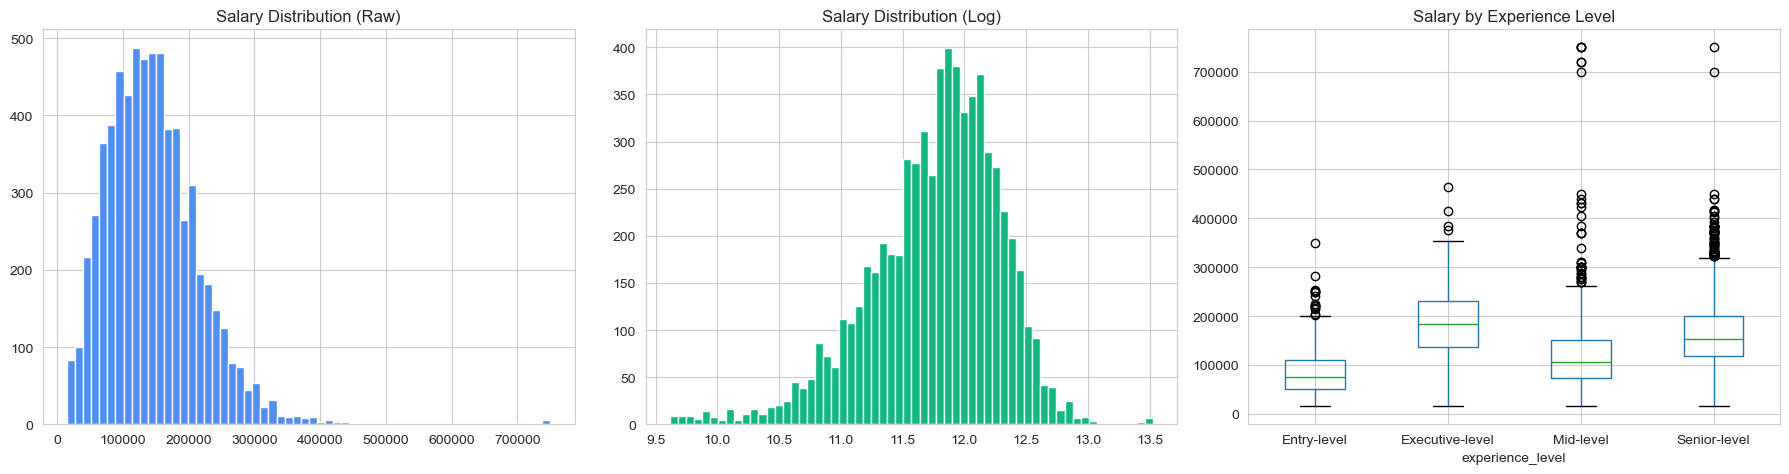

In [8]:
# Target distribution — raw vs log
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['salary_in_usd'], bins=60, color='#4f8ef7', edgecolor='white')
axes[0].set_title('Salary Distribution (Raw)')

axes[1].hist(np.log1p(df['salary_in_usd']), bins=60, color='#10b981', edgecolor='white')
axes[1].set_title('Salary Distribution (Log)')

df.boxplot(column='salary_in_usd', by='experience_level', ax=axes[2])
axes[2].set_title('Salary by Experience Level')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
# Categorical cardinality
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col:30s}: {df[col].nunique():4d} unique  | top-3: {df[col].value_counts().index[:3].tolist()}")

job_title                     :  132 unique  | top-3: ['Data Engineer', 'Data Scientist', 'Data Analyst']
experience_level              :    4 unique  | top-3: ['Senior-level', 'Mid-level', 'Entry-level']
employment_type               :    4 unique  | top-3: ['Full-time', 'Contract', 'Part-time']
work_models                   :    3 unique  | top-3: ['On-site', 'Remote', 'Hybrid']
employee_residence            :   87 unique  | top-3: ['United States', 'United Kingdom', 'Canada']
salary_currency               :   22 unique  | top-3: ['USD', 'GBP', 'EUR']
company_location              :   75 unique  | top-3: ['United States', 'United Kingdom', 'Canada']
company_size                  :    3 unique  | top-3: ['Medium', 'Large', 'Small']


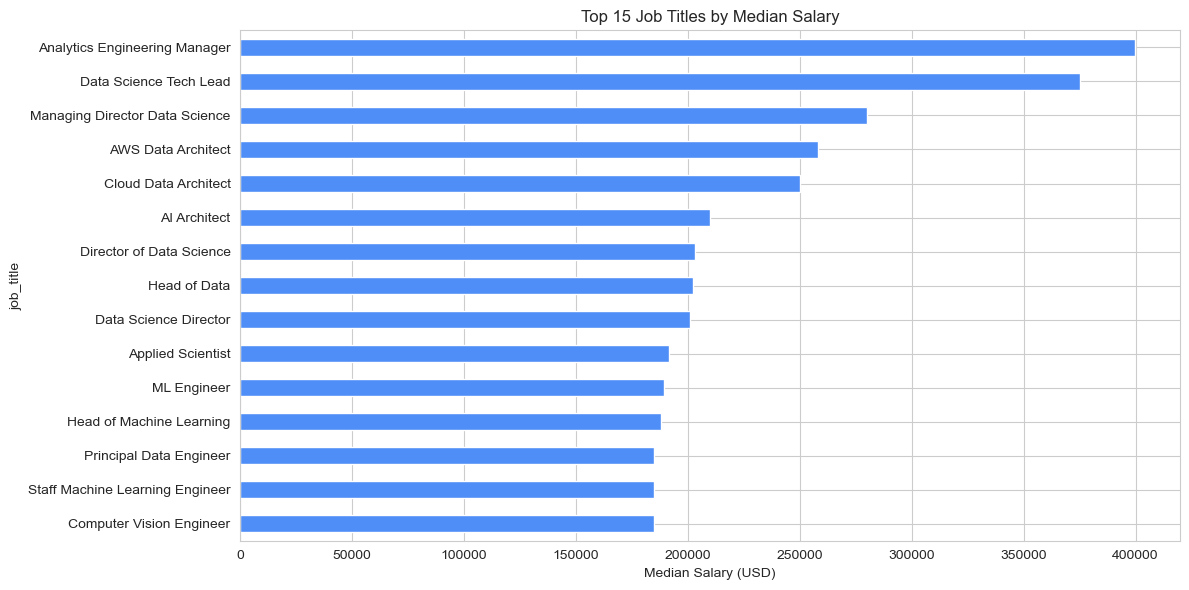

In [10]:
# Top 15 job titles by median salary
top_titles = df.groupby('job_title')['salary_in_usd'].median().sort_values(ascending=False).head(15)
top_titles.plot(kind='barh', color='#4f8ef7')
plt.gca().invert_yaxis()
plt.xlabel('Median Salary (USD)')
plt.title('Top 15 Job Titles by Median Salary')
plt.tight_layout()
plt.show()

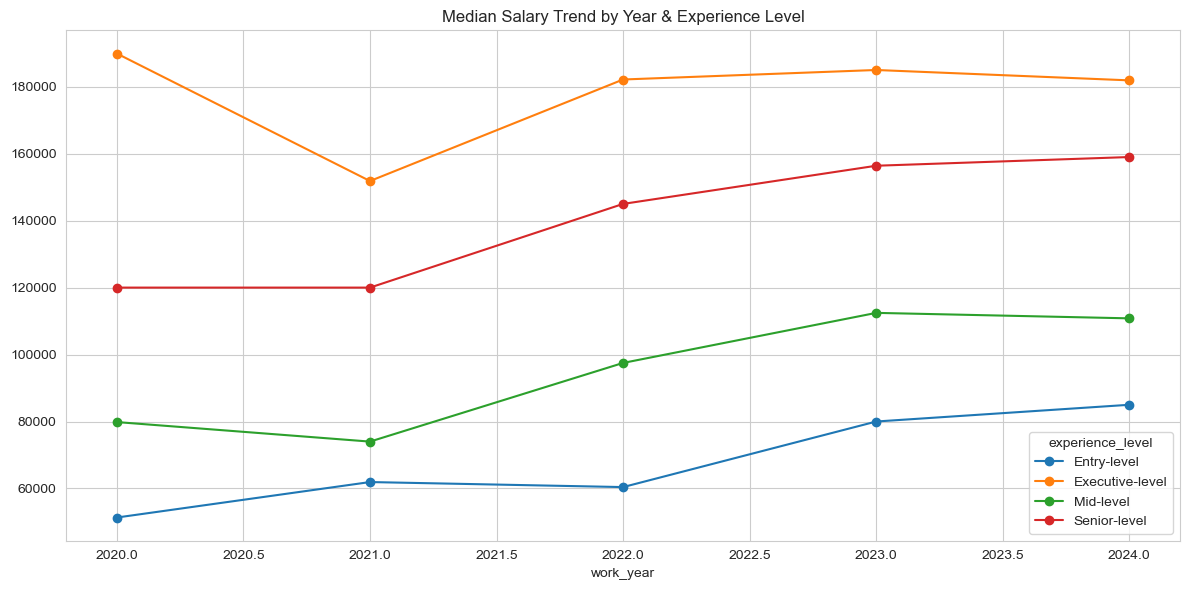

In [11]:
# Salary trends by year & experience
pivot = df.pivot_table(values='salary_in_usd', index='work_year',
                        columns='experience_level', aggfunc='median')
pivot.plot(marker='o')
plt.title('Median Salary Trend by Year & Experience Level')
plt.tight_layout()
plt.show()

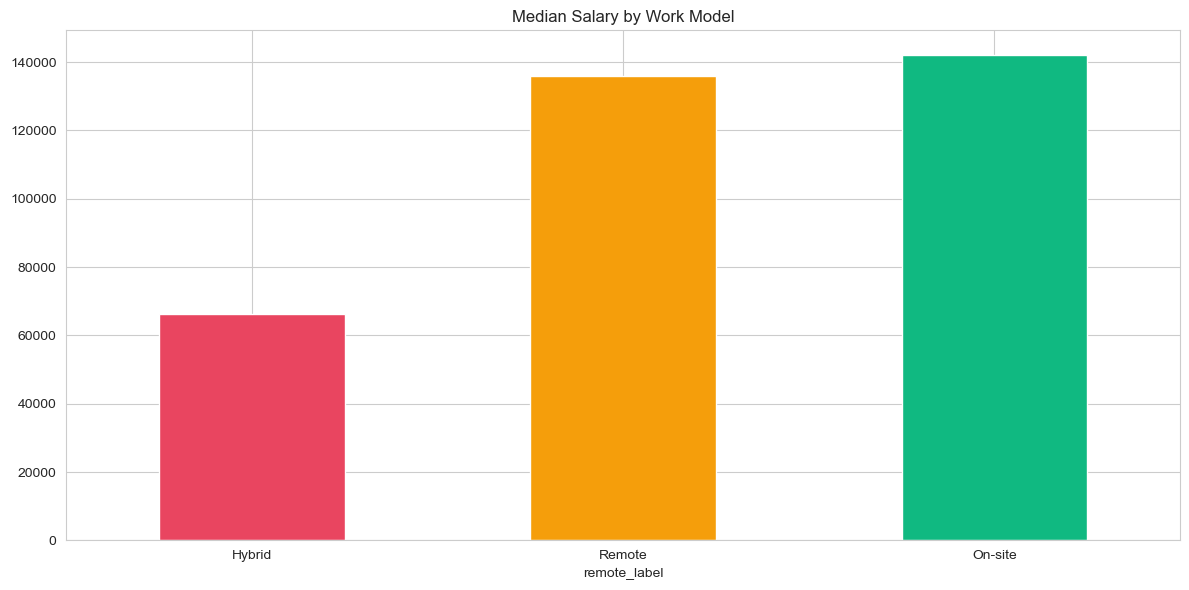

In [24]:
# Map FROM strings TO strings (or to numbers)
remote_map = {'On-site': 'On-site', 'Hybrid': 'Hybrid', 'Remote': 'Remote'}
df['remote_label'] = df['work_models'].map(remote_map)

# Then plot
df.groupby('remote_label')['salary_in_usd'].median().sort_values().plot(
    kind='bar', color=['#e94560','#f59e0b','#10b981'], edgecolor='white')
plt.title('Median Salary by Work Model')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

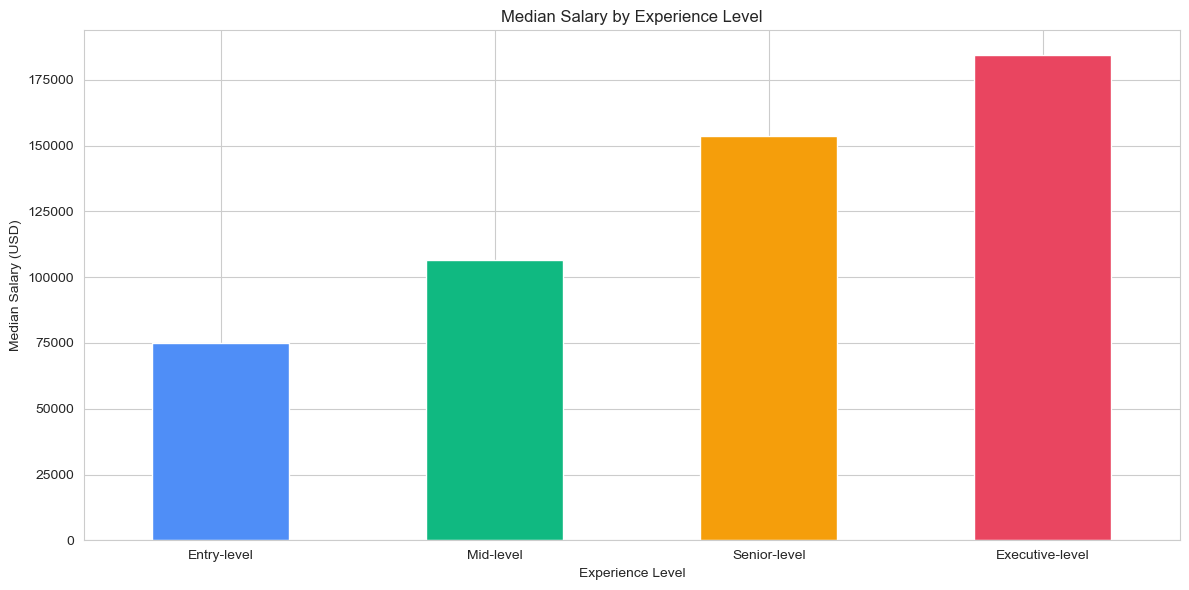

In [70]:
##Expereince level
exp_order = ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']

df.groupby('experience_level')['salary_in_usd'].median().reindex(exp_order).plot(
    kind='bar', color=['#4f8ef7','#10b981','#f59e0b','#e94560'], edgecolor='white')

plt.title('Median Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Median Salary (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [74]:
print(df['company_size'].unique())

['Medium' 'Large' 'Small']


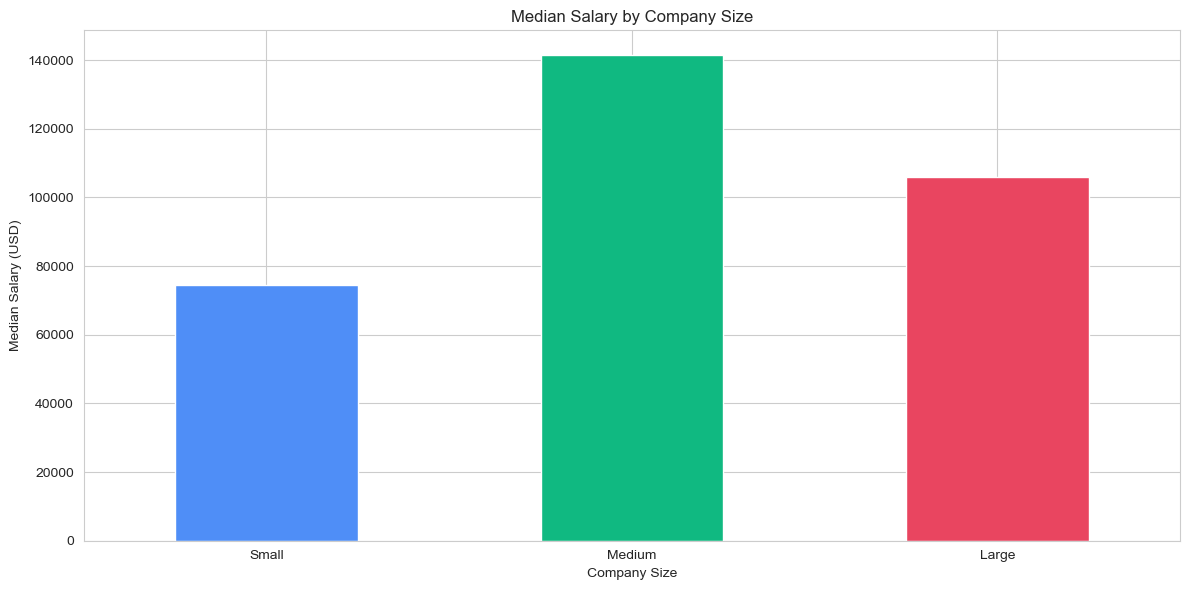

In [75]:
size_order = ['Small', 'Medium', 'Large']

df.groupby('company_size')['salary_in_usd'].median().reindex(size_order).plot(
    kind='bar', color=['#4f8ef7','#10b981','#e94560'], edgecolor='white')

plt.title('Median Salary by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Median Salary (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##Feature Engineering

In [ ]:
# Ordinal encoding with domain knowledge
exp_map = {
    'Entry-level':     0,
    'Mid-level':       1,
    'Senior-level':    2,
    'Executive-level': 3
}

employment_map = {
    'Part-time':  0,
    'Freelance':  1,
    'Contract':   2,
    'Full-time':  3
}

company_size_map = {
    'Small':  0,
    'Medium': 1,
    'Large':  2
}

work_model_map = {
    'On-site': 0,
    'Hybrid':  50,
    'Remote':  100
}

df_fe = df.copy()

df_fe['experience_rank']   = df_fe['experience_level'].map(exp_map)
df_fe['employment_rank']   = df_fe['employment_type'].map(employment_map)
df_fe['company_size_rank'] = df_fe['company_size'].map(company_size_map)
df_fe['remote_ratio']      = df_fe['work_models'].map(work_model_map)

# Verify — should show 0 NaNs for all 4 columns
print(df_fe[['experience_rank','employment_rank','company_size_rank','remote_ratio']].isnull().sum())

experience_rank      0
employment_rank      0
company_size_rank    0
remote_ratio         0
dtype: int64

✅ Cell 11 done


In [78]:
def categorize_job(title):
    t = title.lower()
    if any(x in t for x in ['machine learning', 'ml engineer', 'mlops']):
        return 'ML Engineering'
    elif any(x in t for x in ['data scientist', 'research scientist']):
        return 'Data Science'
    elif any(x in t for x in ['data engineer', 'etl', 'pipeline']):
        return 'Data Engineering'
    elif any(x in t for x in ['analyst', 'analytics']):
        return 'Analytics'
    elif any(x in t for x in ['manager', 'director', 'head', 'lead', 'vp', 'chief']):
        return 'Management'
    elif 'architect' in t:
        return 'Architecture'
    elif any(x in t for x in ['ai', 'nlp', 'computer vision']):
        return 'AI / Research'
    elif any(x in t for x in ['bi', 'business intelligence']):
        return 'BI / Reporting'
    else:
        return 'Other'

df_fe['job_category'] = df_fe['job_title'].apply(categorize_job)

# Check the distribution
print(df_fe['job_category'].value_counts())


job_category
Data Science        1486
Analytics           1476
Data Engineering    1357
ML Engineering       943
Other                564
Management           291
Architecture         191
AI / Research        147
BI / Reporting       144
Name: count, dtype: int64


In [79]:
# Frequency encoding
residence_freq = df_fe['employee_residence'].value_counts() / len(df_fe)
location_freq  = df_fe['company_location'].value_counts()  / len(df_fe)

df_fe['residence_freq']        = df_fe['employee_residence'].map(residence_freq)
df_fe['company_location_freq'] = df_fe['company_location'].map(location_freq)

# Verify — should be 0 NaNs
print(df_fe[['residence_freq','company_location_freq']].isnull().sum())

residence_freq           0
company_location_freq    0
dtype: int64


In [80]:
# Interaction features
# experience × company size — senior at large company earns very differently
df_fe['exp_x_company_size'] = df_fe['experience_rank'] * df_fe['company_size_rank']

# Is employee in same country as company?
df_fe['is_local'] = (df_fe['employee_residence'] == df_fe['company_location']).astype(int)

# Fully remote at a large company — typically highest paying combo
df_fe['remote_large'] = ((df_fe['work_models'] == 'Remote') & (df_fe['company_size'] == 'Large')).astype(int)

# How recent is the record — newer = higher salaries generally
df_fe['year_recency'] = df_fe['work_year'] - df_fe['work_year'].min()

# Verify all 4 — should be 0 NaNs
print(df_fe[['exp_x_company_size','is_local','remote_large','year_recency']].isnull().sum())

exp_x_company_size    0
is_local              0
remote_large          0
year_recency          0
dtype: int64


In [81]:
# Target encoding (job_title & job_category)
from category_encoders import TargetEncoder

te = TargetEncoder(cols=['job_title', 'job_category'], smoothing=10)

encoded = te.fit_transform(
    df_fe[['job_title', 'job_category']],
    df_fe['salary_in_usd']
)

df_fe['job_title_encoded']    = encoded['job_title']
df_fe['job_category_encoded'] = encoded['job_category']

# Verify
print(df_fe[['job_title_encoded','job_category_encoded']].isnull().sum())
print('\nSample:')
print(df_fe[['job_title','job_title_encoded']].drop_duplicates().sort_values('job_title_encoded', ascending=False).head(8))

job_title_encoded       0
job_category_encoded    0
dtype: int64

Sample:
                          job_title  job_title_encoded
195                     ML Engineer      198218.442431
26         Director of Data Science      196498.589530
30       Machine Learning Scientist      193471.287454
42                Applied Scientist      190667.285788
84                Research Engineer      183729.363377
72               Research Scientist      180082.028838
1693                   Head of Data      179266.806523
4789  Analytics Engineering Manager      178649.673095


In [83]:
#building the final feature engineering
feature_cols = [
    'experience_rank',
    'employment_rank',
    'company_size_rank',
    'remote_ratio',
    'year_recency',
    'residence_freq',
    'company_location_freq',
    'exp_x_company_size',
    'is_local',
    'remote_large',
    'job_title_encoded',
    'job_category_encoded',
]

X = df_fe[feature_cols].copy()
y = np.log1p(df_fe['salary_in_usd'])

# Drop NaN rows — keep X and y aligned
mask = X.isnull().any(axis=1)
X    = X[~mask].reset_index(drop=True)
y    = y[~mask].reset_index(drop=True)

print(f'Rows dropped due to NaN: {mask.sum()}')
print(f'Final shape — X: {X.shape}, y: {y.shape}')
print(f'NaNs remaining: {X.isnull().sum().sum()}')   # Must be 0


Rows dropped due to NaN: 0
Final shape — X: (6599, 12), y: (6599,)
NaNs remaining: 0


In [84]:
#split the data 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (5279, 12)
X_test:  (1320, 12)
y_train: (5279,)
y_test:  (1320,)


In [85]:
#XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

#LGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)

#Gradient Boost
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=300,
                          random_state=42, subsample=0.8)

In [87]:
#Evaluate the 3 models
def evaluate(name, model):
    preds    = model.predict(X_test)
    rmse     = np.sqrt(mean_squared_error(y_test, preds))
    mae      = mean_absolute_error(y_test, preds)
    r2       = r2_score(y_test, preds)

    # Convert predictions and actuals back to USD, then compute error there
    preds_usd  = np.expm1(preds)
    actual_usd = np.expm1(y_test)
    rmse_usd   = np.sqrt(mean_squared_error(actual_usd, preds_usd))

    print(f'{name:25s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | ~Error: ${rmse_usd:,.0f}')

evaluate('XGBoost',           xgb_model)
evaluate('LightGBM',          lgb_model)
evaluate('Gradient Boosting', gb_model)

XGBoost                   | RMSE: 0.3840 | MAE: 0.3023 | R²: 0.5070 | ~Error: $63,359
LightGBM                  | RMSE: 0.3830 | MAE: 0.2992 | R²: 0.5095 | ~Error: $63,012
Gradient Boosting         | RMSE: 0.3822 | MAE: 0.3009 | R²: 0.5116 | ~Error: $63,069


In [88]:
#Stacking Ensemble
stack_model = StackingRegressor(
    estimators=[
        ('xgb', xgb_model),
        ('lgb', lgb_model),
        ('gb',  gb_model),
    ],
    final_estimator=Ridge(alpha=10),
    cv=5
)

stack_model.fit(X_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_con...
                                            n_estimators=400, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                              ('lgb',
                               LGBMRegressor(colsample_bytree=0.8,
                                             learning_rate=0.05, max_depth=6,
                                             n_estimators=400, num_leaves=63,
                                             random_state=42, subsample=0.8,
                                             verbosity=-1)),
                              ('gb',
                               GradientBoostingRegressor(learning_rate=0.05,
                                                         max_depth=5,
                                                         n_estimators=300,
                                                         random_state=42,
                                                         subsample=0.8))],
                  final_estimator=Ridge(alpha=10))

In [89]:
evaluate('XGBoost',           xgb_model)
evaluate('LightGBM',          lgb_model)
evaluate('Gradient Boosting', gb_model)
evaluate('Stacking Ensemble', stack_model)

XGBoost                   | RMSE: 0.3840 | MAE: 0.3023 | R²: 0.5070 | ~Error: $63,359
LightGBM                  | RMSE: 0.3830 | MAE: 0.2992 | R²: 0.5095 | ~Error: $63,012
Gradient Boosting         | RMSE: 0.3822 | MAE: 0.3009 | R²: 0.5116 | ~Error: $63,069
Stacking Ensemble         | RMSE: 0.3821 | MAE: 0.2997 | R²: 0.5118 | ~Error: $63,105


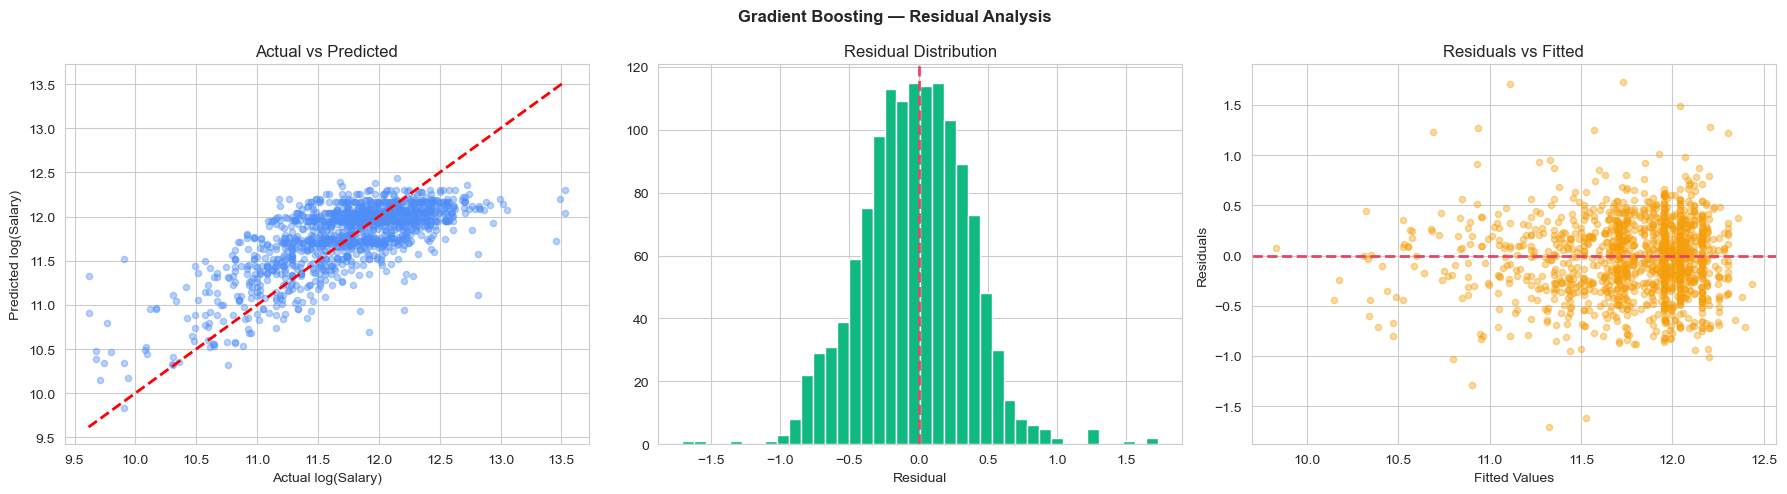

In [90]:
#actual vs Predict 
best_model  = gb_model
best_preds  = best_model.predict(X_test)
residuals   = y_test - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test, best_preds, alpha=0.4, color='#4f8ef7', s=20)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(Salary)')
axes[0].set_ylabel('Predicted log(Salary)')
axes[0].set_title('Actual vs Predicted')

# Residual Distribution
axes[1].hist(residuals, bins=40, color='#10b981', edgecolor='white')
axes[1].axvline(0, color='#e94560', lw=2, linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

# Residuals vs Fitted
axes[2].scatter(best_preds, residuals, alpha=0.4, color='#f59e0b', s=20)
axes[2].axhline(0, color='#e94560', lw=2, linestyle='--')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted')

plt.suptitle('Gradient Boosting — Residual Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

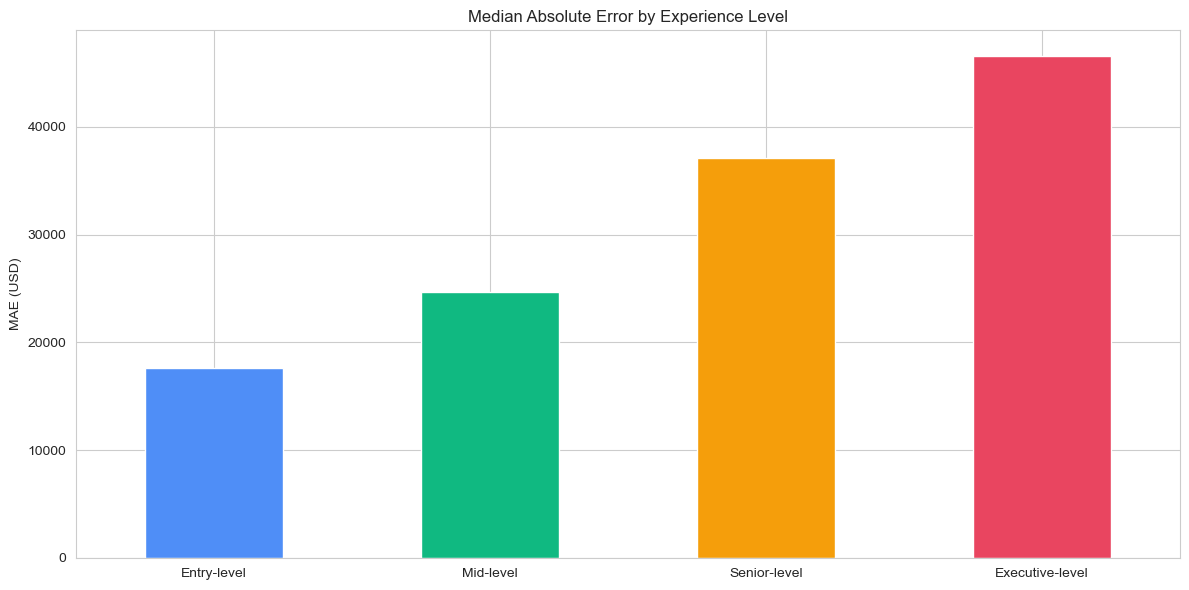

In [91]:
#Error by Experience
error_df = X_test.copy()
error_df['actual_usd']    = np.expm1(y_test)
error_df['predicted_usd'] = np.expm1(best_preds)
error_df['abs_error']     = abs(error_df['actual_usd'] - error_df['predicted_usd'])

exp_label_map = {0: 'Entry-level', 1: 'Mid-level', 2: 'Senior-level', 3: 'Executive-level'}
error_df['exp_label'] = error_df['experience_rank'].map(exp_label_map)

error_by_exp = error_df.groupby('exp_label')['abs_error'].median().reindex(
    ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']
)

error_by_exp.plot(kind='bar',
    color=['#4f8ef7','#10b981','#f59e0b','#e94560'], edgecolor='white')
plt.title('Median Absolute Error by Experience Level')
plt.ylabel('MAE (USD)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


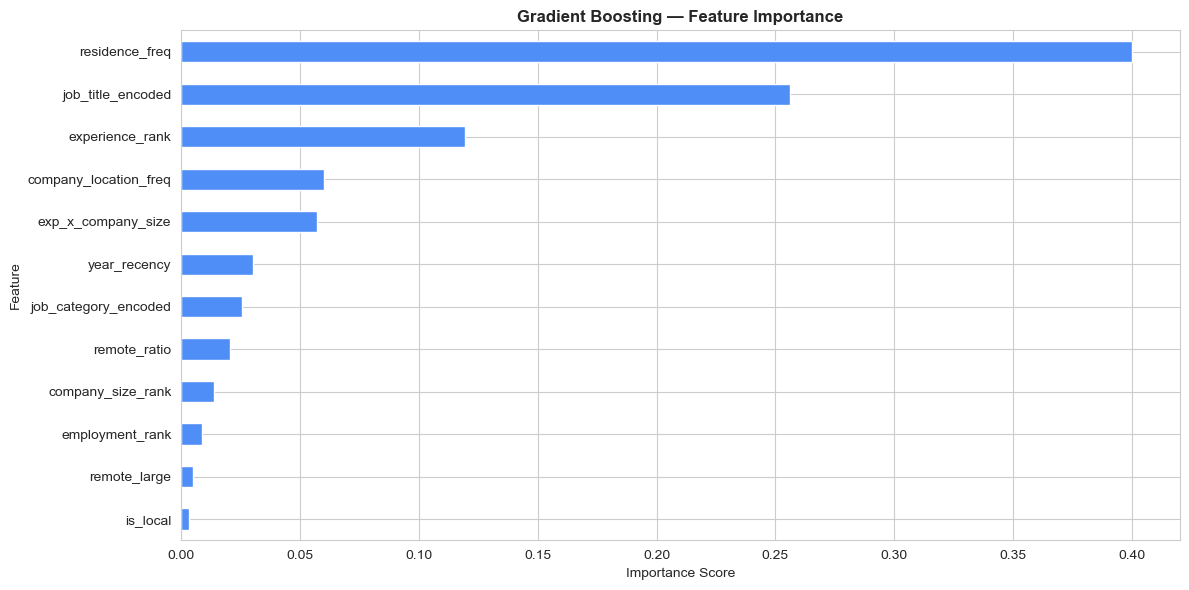

In [92]:
#Feature Importance
importance_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

importance_df.plot(kind='barh', x='Feature', y='Importance',
                   color='#4f8ef7', edgecolor='white', legend=False)
plt.title('Gradient Boosting — Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

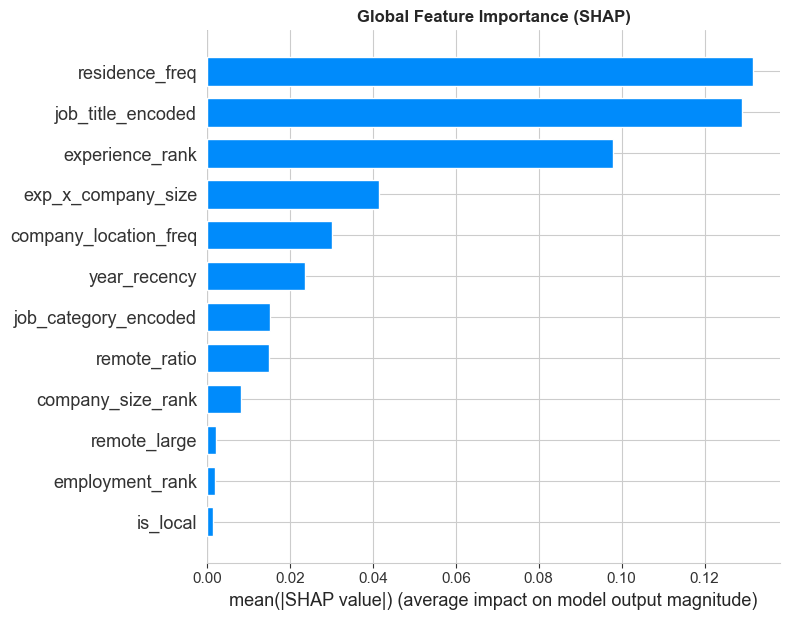

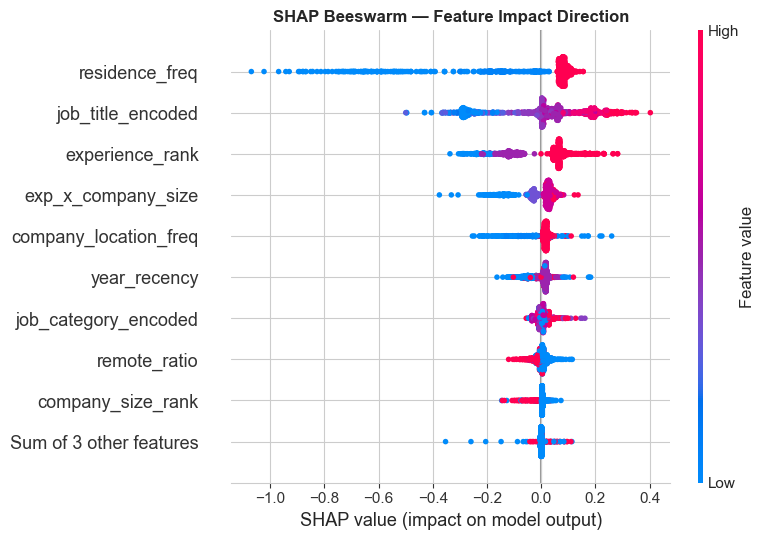

In [106]:
final_model = gb_model

#Shap Feature Engineer
explainer  = shap.TreeExplainer(final_model)
shap_vals  = explainer.shap_values(X_test)

# Global feature importance — mean absolute SHAP
shap.summary_plot(shap_vals, X_test, plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.show()

shap_explanation = shap.Explanation(
    values=shap_vals,
    base_values=np.full(len(shap_vals), explainer.expected_value),
    data=X_test.values,
    feature_names=feature_cols
)

shap.plots.beeswarm(shap_explanation, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plt.show()

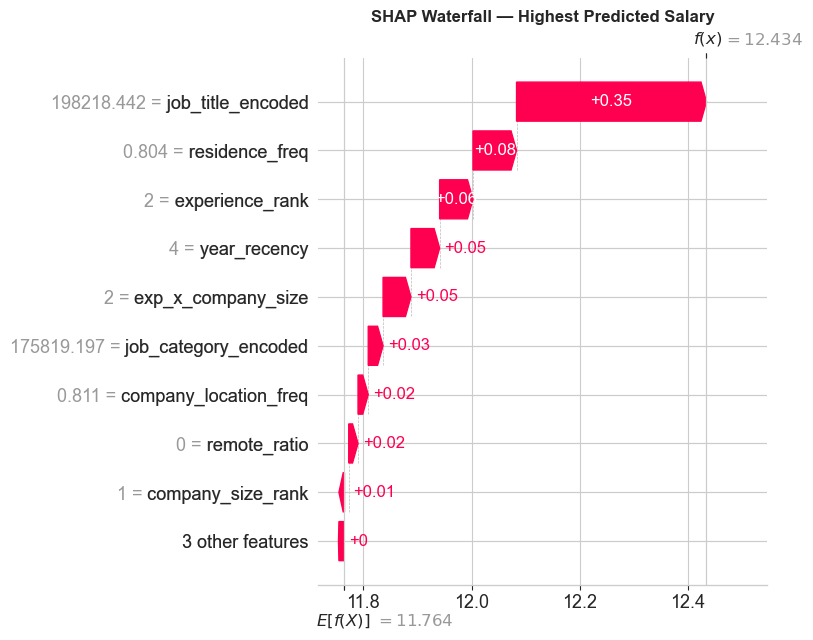

In [104]:
# Explain the highest predicted salary in test set
top_idx  = np.argmax(final_model.predict(X_test))

shap_exp = shap.Explanation(
    values=shap_vals[top_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[top_idx],
    feature_names=feature_cols
)

shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall — Highest Predicted Salary', fontweight='bold')
plt.tight_layout()
plt.show()

In [105]:
print(type(shap_vals))
print(type(shap_vals[0]) if isinstance(shap_vals, list) else 'not a list')
print(np.array(shap_vals).shape)

<class 'numpy.ndarray'>
not a list
(1320, 12)


### Trying Various methods to improve the accuracy

In [93]:
print("Sample count per experience level:")
print(df['experience_level'].value_counts())

print("\nTest set breakdown:")
exp_label_map = {0: 'Entry-level', 1: 'Mid-level', 2: 'Senior-level', 3: 'Executive-level'}
error_df['exp_label'].value_counts().reindex(
    ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']
)

Sample count per experience level:
experience_level
Senior-level       4105
Mid-level          1675
Entry-level         565
Executive-level     254
Name: count, dtype: int64

Test set breakdown:


exp_label
Entry-level        101
Mid-level          346
Senior-level       816
Executive-level     57
Name: count, dtype: int64

In [94]:
#working on resampling 
# Install if needed: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# SMOTE works on classification — we need to bin salary into groups first,
# oversample, then use the resampled X with original continuous y

# Create a temporary experience-level target for SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42, k_neighbors=5)

X_resampled, exp_resampled = smote.fit_resample(
    X_train,
    X_train['experience_rank']   # oversample based on experience level
)

# Align y_train to the resampled index
# Since SMOTE creates synthetic rows, we rebuild y from the resampled X
from sklearn.neighbors import KNeighborsRegressor

# Train a KNN to estimate y for synthetic rows
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_resampled = pd.Series(knn.predict(X_resampled))

print(f"Before SMOTE — X_train: {X_train.shape}")
print(f"After  SMOTE — X_train: {X_resampled.shape}")
print(f"\nExperience level distribution after SMOTE:")
print(pd.Series(exp_resampled).map({
    0: 'Entry-level', 1: 'Mid-level',
    2: 'Senior-level', 3: 'Executive-level'
}).value_counts())


Before SMOTE — X_train: (5279, 12)
After  SMOTE — X_train: (8371, 12)

Experience level distribution after SMOTE:
experience_rank
Senior-level       3289
Executive-level    3289
Mid-level          1329
Entry-level         464
Name: count, dtype: int64


In [95]:
gb_model_v2 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

gb_model_v2.fit(X_resampled, y_resampled)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=300,
                          random_state=42, subsample=0.8)

In [96]:
print('── Before SMOTE ──────────────────────────────────')
evaluate('Gradient Boosting v1', gb_model)

print('\n── After SMOTE ───────────────────────────────────')
evaluate('Gradient Boosting v2', gb_model_v2)

── Before SMOTE ──────────────────────────────────
Gradient Boosting v1      | RMSE: 0.3822 | MAE: 0.3009 | R²: 0.5116 | ~Error: $63,069

── After SMOTE ───────────────────────────────────
Gradient Boosting v2      | RMSE: 0.4166 | MAE: 0.3222 | R²: 0.4199 | ~Error: $64,795


In [ ]:
## SMote not worked
## Lets increase the weights and see if it works

In [97]:
# Assign higher weight to underrepresented experience levels
weight_map = {
    0: 1.0,   # Entry-level
    1: 1.0,   # Mid-level
    2: 1.0,   # Senior-level
    3: 3.0    # Executive-level — 3x more attention
}

sample_weights = X_train['experience_rank'].map(weight_map).values

print("Sample weight distribution:")
print(pd.Series(sample_weights).value_counts())

Sample weight distribution:
1.0    5082
3.0     197
Name: count, dtype: int64


In [98]:
gb_model_v2 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

gb_model_v2.fit(X_train, y_train, sample_weight=sample_weights)
print('✅ Retrained with sample weights')

✅ Retrained with sample weights


In [99]:
print('── Without weights ───────────────────────────────')
evaluate('Gradient Boosting v1', gb_model)

print('\n── With weights (3x Executive) ───────────────────')
evaluate('Gradient Boosting v2', gb_model_v2)

── Without weights ───────────────────────────────
Gradient Boosting v1      | RMSE: 0.3822 | MAE: 0.3009 | R²: 0.5116 | ~Error: $63,069

── With weights (3x Executive) ───────────────────
Gradient Boosting v2      | RMSE: 0.3833 | MAE: 0.3012 | R²: 0.5088 | ~Error: $63,163


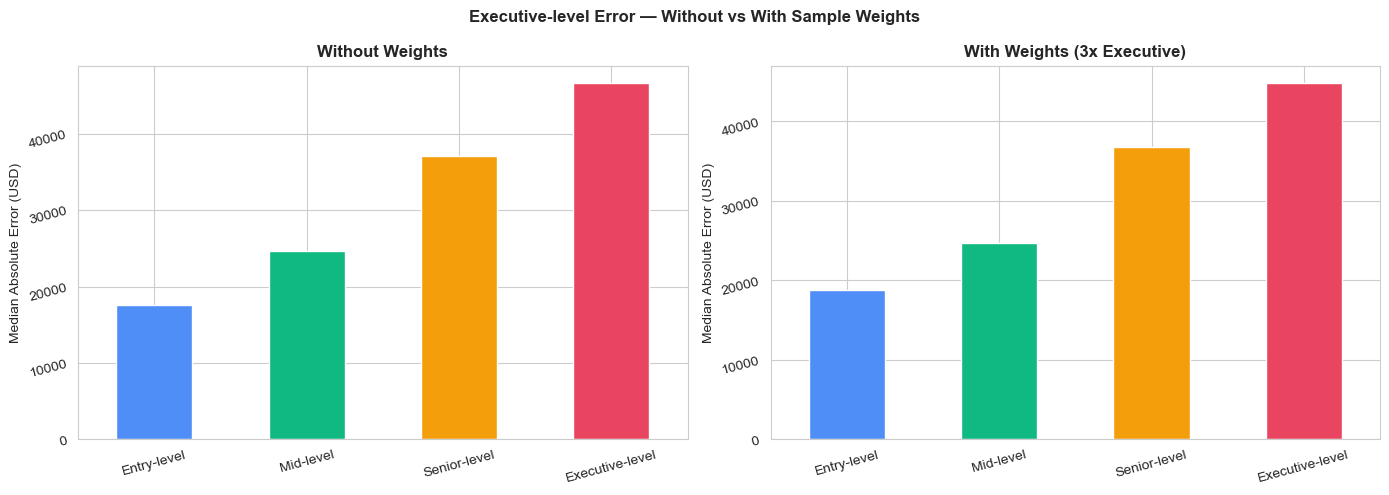

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(
    axes,
    [gb_model, gb_model_v2],
    ['Without Weights', 'With Weights (3x Executive)']
):
    preds  = model.predict(X_test)
    err_df = X_test.copy()
    err_df['actual_usd']    = np.expm1(y_test)
    err_df['predicted_usd'] = np.expm1(preds)
    err_df['abs_error']     = abs(err_df['actual_usd'] - err_df['predicted_usd'])
    err_df['exp_label']     = err_df['experience_rank'].map({
        0: 'Entry-level', 1: 'Mid-level',
        2: 'Senior-level', 3: 'Executive-level'
    })

    err_df.groupby('exp_label')['abs_error'].median().reindex(
        ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']
    ).plot(kind='bar', ax=ax,
           color=['#4f8ef7','#10b981','#f59e0b','#e94560'],
           edgecolor='white')

    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Median Absolute Error (USD)')
    ax.set_xlabel('')
    ax.tick_params(rotation=15)

plt.suptitle('Executive-level Error — Without vs With Sample Weights',
             fontweight='bold')
plt.tight_layout()
plt.show()